# Match labelled rows with LLM-extracted rows
1. Load data
2. Vectorize rows
3. Match rows 
4. Compute accuracy


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import geopy as gpy
import time
import itertools
import regex as re
from matplotlib import pyplot as plt
from src.data import *
from src.plot_functions import *
from src.post_process_functions import *
from src.geocoding import *
from src.hazard_def import *
from src.impact_def import *
from src.sanity_checks import *



## Load data

In [3]:
#load data (model)
post_processed = True #load or not post_processed data
model_name = "meta-llama/llama-4-scout-17b-16e-instruct"
nreports = 50
res_savename = f"post_processed_llm_response_impact_labelled_reports_{model_name.replace('/', '_')}.csv" if post_processed else f"llm_response_impact_labelled_reports_{model_name.replace('/', '_')}.csv"
extracted_df = pd.read_csv(DATA_OUT_PROC+res_savename)

#load data (labelled)
res_savename = "post_processed_labelled_reports_impacts_all.csv" if post_processed else "labelled_reports_impacts_all.csv"
labelled_df = pd.read_csv(DATA_OUT_PROC+res_savename)


In [4]:
#load geocoded data
post_processed = True #load or not post_processed data
model_name = "meta-llama/llama-4-scout-17b-16e-instruct"
nreports = 50
res_savename = f"post_processed_llm_response_impact_labelled_reports_{model_name.replace('/', '_')}_geo.gpkg"
extracted_df = gpd.read_file(DATA_OUT_PROC+res_savename)

#load data (labelled)
res_savename = "post_processed_labelled_reports_impacts_all_geo.gpkg"
labelled_df = gpd.read_file(DATA_OUT_PROC+res_savename)

In [5]:
#reformat output
num_cols = ["impactValue"]#"startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"
list_cols = ["country","location", "hazards", "impactsAnnotation"]
labelled_df = format_output(labelled_df, num_cols=num_cols, list_cols=list_cols)
extracted_df = format_output(extracted_df, num_cols=num_cols, list_cols=list_cols)
combined_df = pd.concat([labelled_df, extracted_df])


## Match
1. Vectorize columns that need to be compared using cosine similarity
2. Compute cosine similarity for those columns for each possible extracted-labelled pair
3. Add absolute difference of impactValue between each possible extracted-labelled pair.
    Need to consider NaN from not NaN separately. Only try matching non-NaNs with non-NaNs 
    (and nans with nan?)
4. Compute Intersection-Over-Union of polygons for each possible pair
5. Match by maximizing similarity and -impactvalu_idff and -IoT. Allow for more than one match.  


In [65]:
from sklearn.metrics.pairwise import cosine_similarity

def vectorize(cell_values, unique_values):
    """vectorizing function for categorical columns"""
    #cell_values = list() if not cell_values else cell_values
    cell_values = [cell_values] if not isinstance(cell_values, list) else cell_values
    vector = [1 if unique_value in cell_values else 0 for unique_value in unique_values]
    return np.array(vector)

def make_cosine_matrix(vec_df1, vec_df2, matching_cols):
    """Build cosine similarity matrix based on matching columns of vectorized dataframes"""
    sim_mat = np.full((len(vec_df1), len(vec_df2), len(matching_cols)), np.nan)

    for k, col in enumerate(matching_cols):
        # Convert Series of arrays/lists to 2D numpy arrays
        X = np.stack(vec_df1[col].values) #nsamples, nfeatures
        Y = np.stack(vec_df2[col].values)
        # Compute cosine similarity
        sim_mat[:,:,k] = cosine_similarity(X, Y)
    return sim_mat

def split_nans(df,key):
    """split a dataframe into two, according to whether the column key contains nans"""
    return df[~df[key].isna()], df[df[key].isna()]

def compute_iou(gdf_left, gdf_right):
    """Compute intersections over union between all rows of two geodataframes."""
    # Example: ensure both are in the same CRS
    gdf_left = gdf_left.to_crs(gdf_right.crs)

    # Precompute areas
    left_areas = gdf_left.geometry.area.values
    right_areas = gdf_right.geometry.area.values

    # Create empty matrix for IoUs
    iou_matrix = np.zeros((len(gdf_left), len(gdf_right)))

    # Compute pairwise IoUs
    for i, geom_left in enumerate(gdf_left.geometry):
        for j, geom_right in enumerate(gdf_right.geometry):
            intersection = geom_left.intersection(geom_right)
            if not intersection.is_empty:
                inter_area = intersection.area
                union_area = left_areas[i] + right_areas[j] - inter_area
                iou_matrix[i, j] = inter_area / union_area if union_area != 0 else 0

    return iou_matrix

def calc_abs_value_diff(df1, df2, col):
    """Compute absolute value difference between two columns of a dataframe"""
    value_diff = np.abs((df1[col].values.reshape(-1, 1)
                         - df2[col].values.reshape(1, -1))
                        / df1[col].values.reshape(-1, 1))
    return value_diff

In [85]:
geo_match = True
value_match_pre = False #minimize diff of impactValue simultaneously as cat columns
value_match_post = True #minimize diff of impactValue after matching of cat columns

unique_countries_ISO = [country.alpha_3 for country in pycountry.countries]
unique_country_names = [country.name for country in pycountry.countries]
pattern = '|'.join(map(re.escape, unique_country_names))

unique_dict = {#mapping dictonary
    'hazards' : hazard_main_types_emdat_extended,
    'country' : unique_country_names,
    'startYear' : np.arange(1980, 2025).tolist(),
    'startMonth' : np.arange(1, 13).tolist(),
    'startDay' : np.arange(1, 32).tolist(),
    'endYear' : np.arange(1980, 2025).tolist(),
    'endMonth' : np.arange(1, 13).tolist(),
    'endDay' : np.arange(1, 32).tolist(),
    'impactSubtype' : impactSubtype_list,
    'impactUnit' : combined_df.impactUnit.unique().tolist()
}

match_idx = []
matching_cols_cat = list(unique_dict.keys()) #only categorical cols used for cosine similarity
matching_cols_all = cp.copy(matching_cols_cat) #all matching columns
if geo_match:
    matching_cols_all.append("geometry")
if value_match_pre or value_match_post:
    matching_cols_all.append("impactValue")

for appeal, ext_group in extracted_df.groupby("appealCode"):
    ext_group = ext_group.reset_index(drop=False, names=["orig_index"]) #need to reset index to get indices for numpy arrays
    lab_group = labelled_df[labelled_df["appealCode"] == appeal].reset_index(drop=False, names=["orig_index"])

    if lab_group.shape[0] == 0:
        continue

    ext_vect_df = pd.DataFrame(columns=matching_cols_cat)
    lab_vect_df = pd.DataFrame(columns=matching_cols_cat)

    #vectorize
    for col in matching_cols_cat:
        ext_vect_df[col] = ext_group[col].apply(vectorize, unique_values=unique_dict[col])
        lab_vect_df[col] = lab_group[col].apply(vectorize, unique_values=unique_dict[col])

    #compute cosine distance
    dist_mat = make_cosine_matrix(ext_vect_df, lab_vect_df, matching_cols_cat)

    ## TODO ADD IOUs
    if geo_match:
        #only compute ious on intersections to speed up
        #joined = gpd.sjoin(ext_group, lab_group, how="inner", predicate="intersects")
        #expand dist_mat to store results
        iou_mat = compute_iou(ext_group, lab_group)
        dist_mat = np.append(dist_mat, iou_mat[:,:, None], axis=2)

    #need to separate Nans from not Nans
    #split
    not_nan_ext_df, nan_ext_df = split_nans(ext_group,"impactValue")
    not_nan_lab_df, nan_lab_df = split_nans(lab_group,"impactValue")

    #retrieve positional indices
    nan_id_ext = nan_ext_df.index.values
    nan_id_lab = nan_lab_df.index.values
    not_nan_id_ext = not_nan_ext_df.index.values
    not_nan_id_lab = not_nan_lab_df.index.values

    #remove impactValue nans from dist matrix
    if len(nan_id_ext):
        if len(nan_id_lab):
            dist_mat_notna = np.delete(np.delete(dist_mat, nan_id_ext, axis=0), nan_id_lab, axis=1)
            dist_mat_na = dist_mat[nan_id_ext, :, :][:,nan_id_lab,:]
        else:
            dist_mat_notna = np.delete(dist_mat, nan_id_ext, axis=0)
            dist_mat_na = dist_mat[nan_id_ext, :, :]
    else:
        if len(nan_id_lab):
            dist_mat_notna = np.delete(dist_mat, nan_id_lab, axis=1)
            dist_mat_na = None
        else:
            dist_mat_notna = dist_mat
            dist_mat_na = None

    #calculate diff
    if value_match_pre:
        value_diff = 1 - calc_abs_value_diff(not_nan_ext_df, not_nan_lab_df, "impactValue")
        dist_mat_notna = np.append(dist_mat_notna, value_diff[:,:, None], axis=2)
        if dist_mat_na is not None:#need to append cols of nans to dist_mat_na to keep array sizes consistent
            dist_mat_na = np.append(dist_mat_na, np.full((dist_mat_na.shape[0], dist_mat_na.shape[1], 1), np.nan), axis=2)
    #initialize
    reid_match_ext = np.array([])
    reid_match_lab = np.array([])
    accuracy_matrix = []#np.array([])#np.full((len(vec_df1), len(vec_df2), len(matching_cols)), np.nan)

    #find possible candidates based on max similarity
    if dist_mat_notna.size != 0:
        agg_sim_notna = np.nansum(dist_mat_notna, axis=2) #aggregate score for all matching columns (#ext, #lab)
        max_sim_notna = np.max(agg_sim_notna, axis=1) #find max similarity value (#ext)
        id_match_ext_notna, id_match_lab_notna = np.where(agg_sim_notna == max_sim_notna[:,None]) #possible candidates with max similarity

        if value_match_post:
            #calculate diff among best candidates
            value_diff = calc_abs_value_diff(not_nan_ext_df.iloc[id_match_ext_notna], not_nan_lab_df.iloc[id_match_lab_notna], "impactValue")
            min_diff = np.min(value_diff, axis=1) #find min diff among possible candidates
            id_min_ext_notna, id_min_lab_notna = np.where(value_diff == min_diff)
            id_match_ext_notna = id_match_ext_notna[id_min_ext_notna]
            id_match_lab_notna = id_match_lab_notna[id_min_lab_notna]
            # add value diff to array to store it
            value_diff_all = calc_abs_value_diff(not_nan_ext_df, not_nan_lab_df, "impactValue")
            dist_mat_notna = np.append(dist_mat_notna, value_diff_all[:,:, None], axis=2)
            if dist_mat_na is not None:#need to append cols of nans to dist_mat_na to keep array sizes consistent
                dist_mat_na = np.append(dist_mat_na, np.full((dist_mat_na.shape[0], dist_mat_na.shape[1], 1), np.nan), axis=2)

        #reindex back in original df
        reid_match_ext_notna = not_nan_ext_df.iloc[id_match_ext_notna]["orig_index"].values.flatten()
        reid_match_lab_notna = not_nan_lab_df.iloc[id_match_lab_notna]["orig_index"].values.flatten()
        reid_match_ext = np.append(reid_match_ext, reid_match_ext_notna)
        reid_match_lab = np.append(reid_match_lab, reid_match_lab_notna)
        accuracy_matrix.append(dist_mat_notna[id_match_ext_notna, id_match_lab_notna, :])

    elif value_match_post:
        #need to append cols of nan to keep dim consistent if there are no impactValues
        dist_mat_notna = np.append(dist_mat_notna, np.full((dist_mat_notna.shape[0], dist_mat_notna.shape[1], 1), np.nan), axis=2)
        if dist_mat_na is not None:#need to append cols of nans to dist_mat_na to keep array sizes consistent
            dist_mat_na = np.append(dist_mat_na, np.full((dist_mat_na.shape[0], dist_mat_na.shape[1], 1), np.nan), axis=2)


    #find possible candidates based on max similarity for
    if dist_mat_na is not None:
        agg_sim_na = np.nansum(dist_mat_na, axis=2) #aggregate score for all matching columns (#ext, #lab)
        max_sim_na = np.max(agg_sim_na, axis=1) #find max similarity value (#ext)
        id_match_ext_na, id_match_lab_na = np.where(agg_sim_na == max_sim_na[:,None]) #possible candidates with max similarity
        reid_match_ext_na = nan_ext_df.iloc[id_match_ext_na]["orig_index"].values.flatten()
        reid_match_lab_na = nan_lab_df.iloc[id_match_lab_na]["orig_index"].values.flatten()
        reid_match_ext = np.append(reid_match_ext, id_match_ext_na)
        reid_match_lab = np.append(reid_match_lab, id_match_lab_na)
        accuracy_matrix.append(dist_mat_na[id_match_ext_na, id_match_lab_na, :])
    #write as df
    id_accuracy_array = np.append(np.stack((reid_match_ext, reid_match_lab),axis=1),np.concatenate(accuracy_matrix),axis=1)
    print(id_accuracy_array.shape)
    match_idx.append(pd.DataFrame(id_accuracy_array,
                                  columns = ["ext_match_id", "lab_match_id"]+matching_cols_all))
match_idx_df = pd.concat(match_idx)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  left_areas = gdf_left.geometry.area.values
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  right_areas = gdf_right.geometry.area.values


(9, 14)
(11, 14)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  left_areas = gdf_left.geometry.area.values
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  right_areas = gdf_right.geometry.area.values
/Users/lseverino/miniforge3/envs/como_proj4/lib/python3.9/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.

(35, 14)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  left_areas = gdf_left.geometry.area.values
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  right_areas = gdf_right.geometry.area.values
/Users/lseverino/miniforge3/envs/como_proj4/lib/python3.9/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


...

(24, 14)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  left_areas = gdf_left.geometry.area.values
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  right_areas = gdf_right.geometry.area.values


(10, 14)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  left_areas = gdf_left.geometry.area.values
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_8326/80892605.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  right_areas = gdf_right.geometry.area.values
/Users/lseverino/miniforge3/envs/como_proj4/lib/python3.9/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


(21, 14)


In [86]:
match_idx_df

,ext_match_id,lab_match_id,hazards,country,startYear,startMonth,startDay,endYear,endMonth,endDay,impactSubtype,impactUnit,geometry,impactValue
0,22.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.713616
1,25.0,8.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.835715
2,25.0,8.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.835715
3,25.0,8.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.835715
4,30.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.596941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,4.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,NaN
17,5.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN
18,5.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN
19,5.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN


In [87]:
#join extracted and labelled dataframes
#repeated_df = labelled_df.loc[np.repeat(match_idx, 1)].reset_index(drop=True)
#repeated_df = repeated_df.add_suffix('_matched')
#joined_df = pd.concat([extracted_df, repeated_df], axis=1)

matched_df = pd.concat([extracted_df.loc[match_idx_df["ext_match_id"].values].reset_index(drop=True),
                        labelled_df.loc[match_idx_df["lab_match_id"].values].add_suffix('_matched').reset_index(drop=True),
                        match_idx_df.drop(["ext_match_id", "lab_match_id"], axis=1).reset_index(drop=True).add_suffix('_sim')], axis=1)

In [88]:
matched_df.sort_index(axis=1)

,appealCode,appealCode_matched,comments_matched,country,country_iso3,country_iso3_kw,country_iso3_kw_matched,country_iso3_matched,country_kw,country_matched,...,startDay_matched,startDay_sim,startMonth,startMonth_matched,startMonth_sim,startYear,startYear_matched,startYear_sim,unit_type,unit_type_matched
0,MDRBD022,MDRBD022,NaN,[Bangladesh],NaN,BGD,NaN,NaN,['Bangladesh'],[Bangladesh],...,18.0,0.0,7,7.0,0.0,2019.0,2019.0,1.0,other,other
1,MDRBD022,MDRBD022,NaN,[Bangladesh],NaN,BGD,NaN,NaN,['Bangladesh'],[Bangladesh],...,16.0,0.0,7,7.0,0.0,2019.0,2019.0,1.0,other,other
2,MDRBD022,MDRBD022,NaN,[Bangladesh],NaN,BGD,NaN,NaN,['Bangladesh'],[Bangladesh],...,16.0,0.0,7,7.0,0.0,2019.0,2019.0,1.0,other,other
3,MDRBD022,MDRBD022,NaN,[Bangladesh],NaN,BGD,NaN,NaN,['Bangladesh'],[Bangladesh],...,16.0,0.0,7,7.0,0.0,2019.0,2019.0,1.0,other,other
4,MDRBD022,MDRBD022,NaN,[Bangladesh],NaN,BGD,NaN,NaN,['Bangladesh'],[Bangladesh],...,18.0,0.0,6,7.0,0.0,2020.0,2019.0,0.0,other,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,MDR55001,MDRBD022,NaN,[Tuvalu],NaN,FJI,NaN,NaN,['Fiji'],"[Nepal, India]",...,NaN,0.0,NaN,NaN,0.0,NaN,2019.0,0.0,other,other
377,MDR55001,MDRBD022,NaN,[Kiribati],NaN,FJI,NaN,NaN,['Fiji'],[Bangladesh],...,18.0,0.0,NaN,7.0,0.0,NaN,2019.0,0.0,other,other
378,MDR55001,MDRBD022,NaN,[Kiribati],NaN,FJI,NaN,NaN,['Fiji'],"[Nepal, India]",...,NaN,0.0,NaN,NaN,0.0,NaN,2019.0,0.0,other,other
379,MDR55001,MDRBD022,NaN,[Kiribati],NaN,FJI,NaN,NaN,['Fiji'],[Bangladesh],...,16.0,0.0,NaN,7.0,0.0,NaN,2019.0,0.0,other,other


In [107]:
matched_df[["appealCode", "impactSubtype", "impactSubtype_matched" ,"impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "impactsAnnotation", "impactsAnnotation_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,impactsAnnotation,impactsAnnotation_matched
0,MDRBD022,Affected People,Affected People,7600000.0,people,2176519.0,people,[more than 7.6 million people were affected in...,[DREF operation n MDRBD022 Glide n FL-2019-000...
1,MDRBD022,Residential Buildings,Residential Buildings,600000.0,homes,98571.0,homes,"[approximately 600,000 houses damaged]","[of partially damaged house 98,571 No., Six da..."
2,MDRBD022,Residential Buildings,Residential Buildings,600000.0,homes,98571.0,homes,"[approximately 600,000 houses damaged]","[of partially damaged house 98,571 No., Six da..."
3,MDRBD022,Residential Buildings,Residential Buildings,600000.0,homes,98571.0,homes,"[approximately 600,000 houses damaged]","[of partially damaged house 98,571 No., Six da..."
4,MDRBD022,Affected People,Affected People,5400000.0,people,2176519.0,people,[severe floods that struck Bangladesh during t...,[DREF operation n MDRBD022 Glide n FL-2019-000...
...,...,...,...,...,...,...,...,...,...
376,MDR55001,"Access to Water, Sanitation, and Hygiene",Affected People,414.0,people,1000000.0,people,[A total of13 rainwater harvesting systems ( R...,[While the monsoon season normally brings annu...
377,MDR55001,Access to Healthcare,Affected People,63.0,people,2176519.0,people,[A total of63 community volunteers participate...,[DREF operation n MDRBD022 Glide n FL-2019-000...
378,MDR55001,Access to Healthcare,Affected People,63.0,people,1000000.0,people,[A total of63 community volunteers participate...,[While the monsoon season normally brings annu...
379,MDR55001,Access to Healthcare,Affected People,63.0,people,2100000.0,people,[A total of63 community volunteers participate...,[According to National disaster response coord...


# Stats
1. Compare nb extracted impacts vs labelled (coverage)
    1. by reports
    2. by impact types
2. Compare matched rows 
    1. similarities on categories
    2. impactValue diff
    3. See if stats improve by taking higher level of aggreg (country level)


## Coverage

In [93]:
# coverage grouped by appeal
coverages_by_appeal = {}
for appeal, group_ext in extracted_df.groupby("appealCode"):
    group_lab = labelled_df[labelled_df["appealCode"] == appeal]
    coverage = len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
    print(f"{appeal}: {len(group_ext)} extracted, {len(group_lab)} labelled, {coverage} coverage")
    coverages_by_appeal[appeal] = (len(group_ext), len(group_lab), coverage)
coverage_appeal_df = pd.DataFrame(coverages_by_appeal, index=["nb extracted","nb labelled","coverage"]).T


MDR55001: 8 extracted, 0 labelled, nan coverage
MDRAF014: 14 extracted, 0 labelled, nan coverage
MDRBD022: 11 extracted, 12 labelled, 0.9166666666666666 coverage
MDRBJ019: 5 extracted, 16 labelled, 0.3125 coverage
MDRBR010: 11 extracted, 0 labelled, nan coverage
MDRBZ006: 6 extracted, 0 labelled, nan coverage
MDRCM036: 6 extracted, 0 labelled, nan coverage
MDRCM039: 12 extracted, 18 labelled, 0.6666666666666666 coverage
MDRCN006: 14 extracted, 18 labelled, 0.7777777777777778 coverage
MDRCO023: 10 extracted, 0 labelled, nan coverage
MDRDZ008: 17 extracted, 0 labelled, nan coverage
MDRDZ011: 2 extracted, 0 labelled, nan coverage
MDRGE019: 20 extracted, 0 labelled, nan coverage
MDRGN015: 12 extracted, 0 labelled, nan coverage
MDRGT009: 6 extracted, 0 labelled, nan coverage
MDRHU005: 2 extracted, 0 labelled, nan coverage
MDRID013: 7 extracted, 0 labelled, nan coverage
MDRIN028: 1 extracted, 0 labelled, nan coverage
MDRIQ014: 11 extracted, 8 labelled, 1.375 coverage
MDRKE058: 15 extracted, 

In [94]:
## biased toward SV012 report
coverage_appeal_df.dropna()
nb_extracted = coverage_appeal_df.dropna()["nb extracted"].sum()
nb_labelled = coverage_appeal_df.dropna()["nb labelled"].sum()
avg_coverage_by_appeal = coverage_appeal_df.dropna()["coverage"].mean()
avg_coverage_tot = nb_extracted/nb_labelled


print(f"{nb_extracted} extracted, {nb_labelled} labelled, {avg_coverage_tot} coverage total, {avg_coverage_by_appeal} coverage by report")

155.0 extracted, 415.0 labelled, 0.37349397590361444 coverage total, 1.1991001868535733 coverage by report


<Axes: >

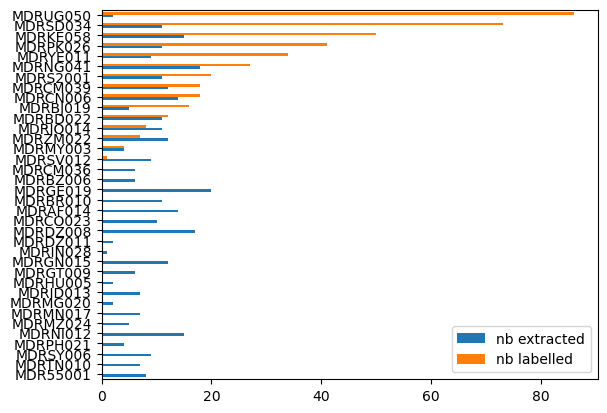

In [95]:
coverage_appeal_df[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh")

In [96]:
# coverage grouped by impactSubtype
coverages_by_subtype = {}
for subtype, group_ext in extracted_df.groupby("impactSubtype"):
    group_lab = labelled_df[labelled_df["impactSubtype"] == subtype]
    coverage = len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
    print(f"{subtype}: {len(group_ext)} extracted, {len(group_lab)} labelled, {coverage} coverage")
    coverages_by_subtype[subtype] = (len(group_ext), len(group_lab), coverage)
coverage_subtype_df = pd.DataFrame(coverages_by_subtype, index=["nb extracted","nb labelled","coverage"]).T



Access to Education: 1 extracted, 2 labelled, 0.5 coverage
Access to Food: 5 extracted, 3 labelled, 1.6666666666666667 coverage
Access to Healthcare: 3 extracted, 5 labelled, 0.6 coverage
Access to Power and Energy: 1 extracted, 0 labelled, nan coverage
Access to Water, Sanitation, and Hygiene: 3 extracted, 1 labelled, 3.0 coverage
Affected Livestock and Animals: 17 extracted, 9 labelled, 1.8888888888888888 coverage
Affected People: 65 extracted, 99 labelled, 0.6565656565656566 coverage
Agriculture Infrastructure: 4 extracted, 3 labelled, 1.3333333333333333 coverage
Crop Production and Forestry: 20 extracted, 24 labelled, 0.8333333333333334 coverage
Displaced People: 18 extracted, 36 labelled, 0.5 coverage
Education Infrastructure: 8 extracted, 7 labelled, 1.1428571428571428 coverage
Healthcare Infrastructure: 5 extracted, 10 labelled, 0.5 coverage
Homeless People: 9 extracted, 9 labelled, 1.0 coverage
Human Deaths: 37 extracted, 21 labelled, 1.7619047619047619 coverage
Human Health an

<Axes: >

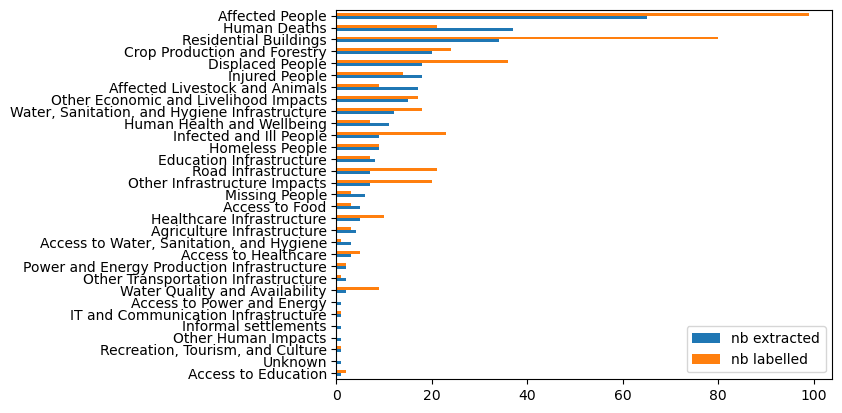

In [97]:
coverage_subtype_df[["nb extracted", "nb labelled"]].sort_values("nb extracted", ascending=True).plot(kind="barh")

## Matched similarity

In [98]:
#similarity global
sim_cols = [col + "_sim" for col in matching_cols_all ]
avg_sim = matched_df[sim_cols].mean()

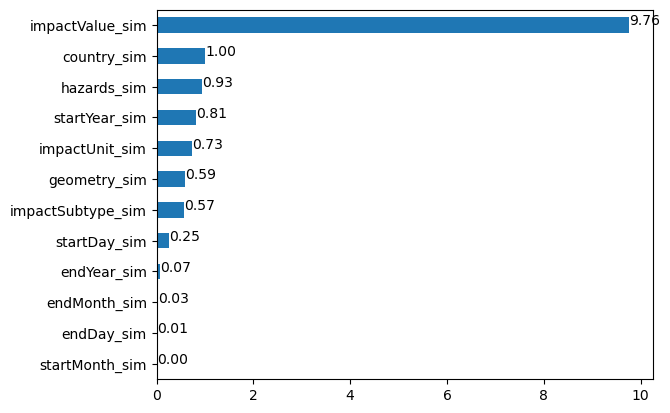

In [99]:
axes = avg_sim.sort_values(ascending=True).plot(kind="barh")
for i, v in enumerate(avg_sim.sort_values(ascending=True)):
    axes.text(v, i, f"{v:.2f}")



<Axes: ylabel='Frequency'>

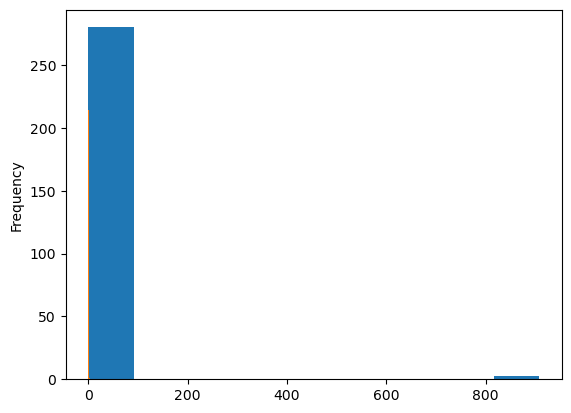

In [ ]:
#investigate impactValue_sim

matched_df["impactValue_sim"].plot(kind="hist") #outlier of more than 800

In [112]:
#check outlier
matched_df[matched_df["impactValue_sim"] > 800].loc[:,["appealCode", "impactSubtype", "impactSubtype_matched" ,"impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "impactsAnnotation", "impactsAnnotation_matched"]]

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,impactsAnnotation,impactsAnnotation_matched
363,MDRZM022,Other Economic and Livelihood Impacts,Crop Production and Forestry,11.0,CHF,10000.0,km**2 of crop production and forestry,"[the IFRC, in support to the ZRCS, launched an...",[Page 1 / 21 DREF Operation Zambia Drought 202...
364,MDRZM022,Other Economic and Livelihood Impacts,Crop Production and Forestry,11.0,CHF,10000.0,km**2 of crop production and forestry,"[the IFRC, in support to the ZRCS, launched an...",[Page 1 / 21 DREF Operation Zambia Drought 202...
365,MDRZM022,Other Economic and Livelihood Impacts,Crop Production and Forestry,11.0,CHF,10000.0,km**2 of crop production and forestry,"[the IFRC, in support to the ZRCS, launched an...",[Page 1 / 21 DREF Operation Zambia Drought 202...


In [113]:
#remove outliers
matched_df = matched_df[matched_df["impactValue_sim"] < 800]

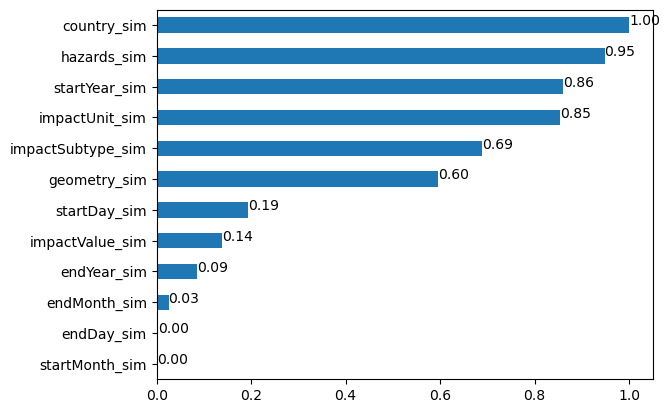

In [117]:
avg_sim = matched_df[sim_cols].mean()
axes = avg_sim.sort_values(ascending=True).plot(kind="barh")
for i, v in enumerate(avg_sim.sort_values(ascending=True)):
    axes.text(v, i, f"{v:.2f}")

In [100]:
# similarity grouped by appealCode
sim_by_subtype = {}
for subtype, group_ext in extracted_df.groupby("impactSubtype"):
    group_lab = labelled_df[labelled_df["impactSubtype"] == subtype]
    coverage = len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
    print(f"{subtype}: {len(group_ext)} extracted, {len(group_lab)} labelled, {coverage} coverage")
    coverages_by_subtype[subtype] = (len(group_ext), len(group_lab), coverage)
coverage_subtype_df = pd.DataFrame(coverages_by_subtype, index=["nb extracted","nb labelled","coverage"]).T

Access to Education: 1 extracted, 2 labelled, 0.5 coverage
Access to Food: 5 extracted, 3 labelled, 1.6666666666666667 coverage
Access to Healthcare: 3 extracted, 5 labelled, 0.6 coverage
Access to Power and Energy: 1 extracted, 0 labelled, nan coverage
Access to Water, Sanitation, and Hygiene: 3 extracted, 1 labelled, 3.0 coverage
Affected Livestock and Animals: 17 extracted, 9 labelled, 1.8888888888888888 coverage
Affected People: 65 extracted, 99 labelled, 0.6565656565656566 coverage
Agriculture Infrastructure: 4 extracted, 3 labelled, 1.3333333333333333 coverage
Crop Production and Forestry: 20 extracted, 24 labelled, 0.8333333333333334 coverage
Displaced People: 18 extracted, 36 labelled, 0.5 coverage
Education Infrastructure: 8 extracted, 7 labelled, 1.1428571428571428 coverage
Healthcare Infrastructure: 5 extracted, 10 labelled, 0.5 coverage
Homeless People: 9 extracted, 9 labelled, 1.0 coverage
Human Deaths: 37 extracted, 21 labelled, 1.7619047619047619 coverage
Human Health an